IPL Player Dataset
   Sl.NO.   PLAYER NAME  AGE COUNTRY  TEAM PLAYING ROLE  T-RUNS  T-WKTS  \
0       1   Abdulla, YA    2      SA  KXIP   Allrounder       0       0   
1       2  Abdur Razzak    2     BAN   RCB       Bowler     214      18   

   ODI-RUNS-S  ODI-SR-B  ...  SR-B  SIXERS  RUNS-C  WKTS  AVE-BL  ECON  SR-BL  \
0           0      0.00  ...   0.0       0     307    15   20.47   8.9  13.93   
1         657     71.41  ...   0.0       0      29     0    0.00  14.5   0.00   

   AUCTION YEAR  BASE PRICE  SOLD PRICE  
0          2009       50000       50000  
1          2008       50000       50000  

[2 rows x 26 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    o

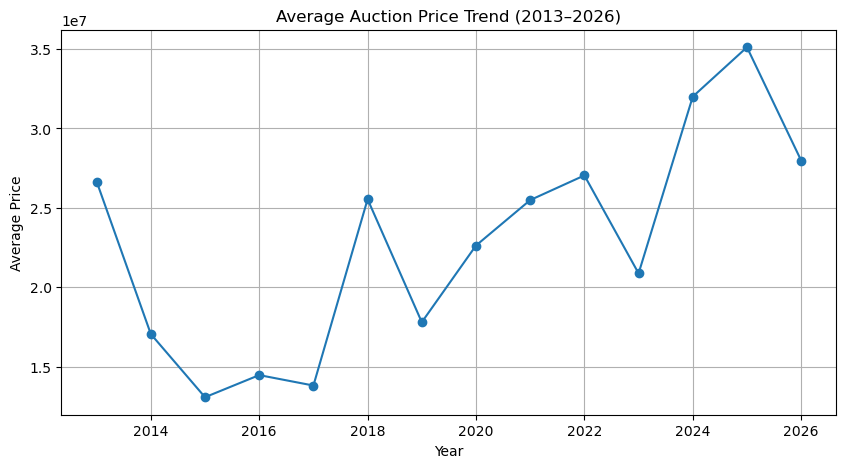


Top 10 Expensive Players
                       Name               TeamName   sold_price
1196           Rishabh Pant   Lucknow Super Giants  270000000.0
1233           Shreyas Iyer           Punjab Kings  267500000.0
1326        Cameron Green    Kolkata Knight Riders  252000000.0
1077       Mitchell  Starc   Kolkata Knight Riders  247500000.0
1181         Venkatesh Iyer  Kolkata Knight Riders  237500000.0
1120           Pat Cummins     Sunrisers Hyderabad  205000000.0
1019            Sam Curran            Punjab Kings  185000000.0
1235         Arshdeep Singh           Punjab Kings  180000000.0
1327  Matheesha Pathirana    Kolkata Knight Riders  180000000.0
1234       Yuzvendra Chahal           Punjab Kings  180000000.0
Merged Shape: (1518, 39)
Matched Players: (445, 39)

Top 10 Undervalued
               Name                     TeamName  value_index
188   Tanmay Mishra  Royal Challengers Bengaluru     0.001194
168     Amit Mishra             Rajasthan Royals     0.001194
320     Amit

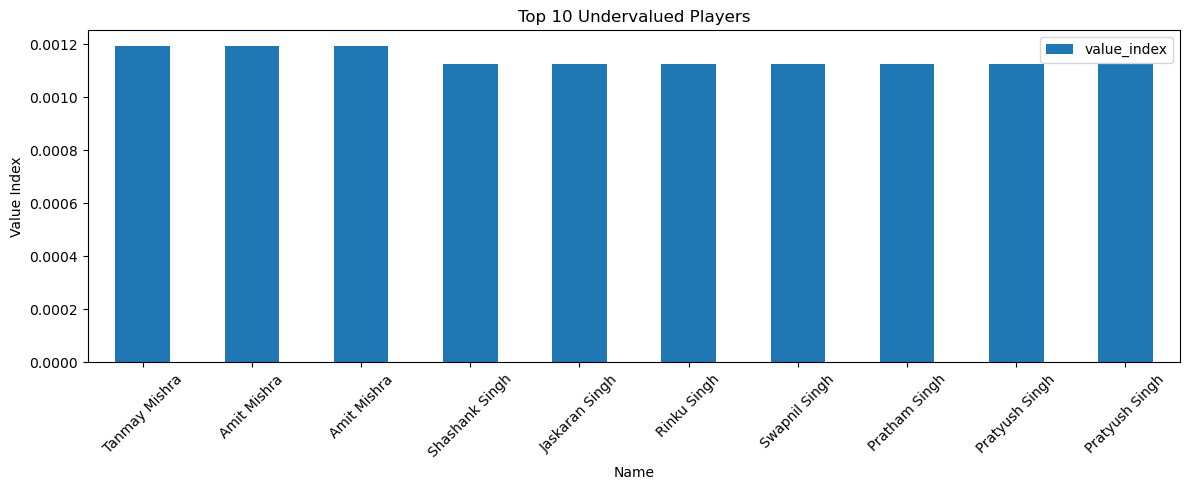


Project Completed Successfully
Final Shape: (445, 41)
(445, 39)


In [44]:
# =========================================================
# IPL AUCTION INTELLIGENCE (2013–2026)
# Goal:
# Identify overvalued & undervalued players using auction data
# =========================================================

# =========================================================
# STEP 1: Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt


# =========================================================
# STEP 2: Load IPL Player Stats Dataset
# =========================================================
print("IPL Player Dataset")

IPL = pd.read_csv("IPL_data.csv")

print(IPL.head(2))
print(IPL.info())

# =========================================================
# STEP 3: Create merge key in IPL dataset
# Example:
# "Dhoni, MS" -> "dhoni"
# =========================================================
IPL["merge_key"] = (
    IPL["PLAYER NAME"]
    .str.lower()
    .str.split(",")
    .str[0]
    .str.strip()
)

print(IPL[["PLAYER NAME","merge_key"]].head())


# =========================================================
# STEP 4: Load all auction files
# =========================================================
auction_files = sorted(
    glob.glob("IPL_Auction_*_Sold_Player.csv")
)

print("\nAuction Files Found:")
print(auction_files)


# =========================================================
# STEP 5: Read all auction files
# =========================================================
all_auction = []

for file in auction_files:

    year = int(file.split("_")[2])

    df = pd.read_csv(file)

    if "Unnamed: 0" in df.columns:
        df.drop("Unnamed: 0", axis=1, inplace=True)

    df["year"] = year

    print(f"\nAuction Data: {year}")
    print(df.head(2))

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    all_auction.append(df)


# =========================================================
# STEP 6: Combine all auction data
# =========================================================
auction = pd.concat(
    all_auction,
    ignore_index=True
)

print("\nCombined Shape:", auction.shape)
print(auction.info())


# =========================================================
# STEP 7: Create merge key in auction dataset
# Example:
# "MS Dhoni" -> "dhoni"
# =========================================================
auction["merge_key"] = (
    auction["Name"]
    .str.lower()
    .str.split()
    .str[-1]
    .str.strip()
)

print(auction[["Name","merge_key"]].head())

# =========================================================
# STEP 8: Clean Price in $
# =========================================================
auction["Price in $"] = (
    auction["Price in $"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

auction["Price in $"] = pd.to_numeric(
    auction["Price in $"],
    errors="coerce"
)

auction["Price_in_rs_from_dollar"] = (
    auction["Price in $"] * 83
)


# =========================================================
# STEP 9: Create sold_price
# =========================================================
auction["sold_price"] = (
    auction["Price in rs"]
    .fillna(auction["Winning Bid in Rs"])
    .fillna(auction["Price_in_rs_from_dollar"])
)

auction["sold_price"] = (
    auction["sold_price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.strip()
)

auction["sold_price"] = pd.to_numeric(
    auction["sold_price"],
    errors="coerce"
)

print("\nFinal Price Nulls:",
      auction["sold_price"].isnull().sum())


# =========================================================
# STEP 10: Clean Team Names
# =========================================================
auction["TeamName"] = (
    auction["TeamName"]
    .str.strip()
    .replace({
        "Royal Challengers Bangalore":
        "Royal Challengers Bengaluru",

        "Kings XI Punjab":
        "Punjab Kings",

        "Delhi Daredevils":
        "Delhi Capitals"
    })
)


# =========================================================
# STEP 11: Clean Roles
# =========================================================
auction["Role"] = (
    auction["Role"]
    .str.strip()
    .replace({
        "Batter": "Batsman",
        "Wicket-Keeper": "Wicket Keeper"
    })
)

print("\nUnique Roles:")
print(auction["Role"].unique())


# =========================================================
# STEP 12: Team Spending
# =========================================================
team_spend = auction.groupby(
    "TeamName"
)["sold_price"].sum()

print("\nTeam Spending")
print(team_spend.sort_values(
    ascending=False
))


# =========================================================
# STEP 13: Role-wise Avg Price
# =========================================================
role_price = auction.groupby(
    "Role"
)["sold_price"].mean()

print("\nRole-wise Avg Price")
print(role_price.sort_values(
    ascending=False
))


# =========================================================
# STEP 14: Auction Trend
# =========================================================
year_trend = auction.groupby(
    "year"
)["sold_price"].mean()

print("\nYear Trend")
print(year_trend)

year_trend.plot(
    marker="o",
    figsize=(10,5)
)

plt.title(
    "Average Auction Price Trend (2013–2026)"
)
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid()
plt.show()


# =========================================================
# STEP 15: Top expensive players
# =========================================================
top_players = auction.sort_values(
    "sold_price",
    ascending=False
)[["Name","TeamName","sold_price"]]

print("\nTop 10 Expensive Players")
print(top_players.head(10))


# =========================================================
# STEP 16: Merge using merge_key
# =========================================================
merged = pd.merge(
    auction,
    IPL,
    on="merge_key",
    how="left"
)

print("Merged Shape:", merged.shape)


# =========================================================
# STEP 17: Keep matched rows
# =========================================================
merged_clean = merged.dropna(
    subset=["PLAYER NAME"]
).copy()

print("Matched Players:",
      merged_clean.shape)


# =========================================================
# STEP 18: Performance Score
# =========================================================
merged_clean["performance_score"] = (
    merged_clean["RUNS-S"] * 0.4 +
    merged_clean["WKTS"] * 15 +
    merged_clean["SR-B"] * 0.3 -
    merged_clean["ECON"] * 3
)


# =========================================================
# STEP 19: Value Index
# =========================================================
merged_clean["value_index"] = (
    merged_clean["performance_score"] /
    merged_clean["sold_price"]
)

merged_clean["value_index"] = (
    merged_clean["value_index"]
    .replace([np.inf, -np.inf], 0)
)


# =========================================================
# STEP 20: Undervalued
# =========================================================
print("\nTop 10 Undervalued")
print(
    merged_clean.sort_values(
        "value_index",
        ascending=False
    )[["Name","TeamName","value_index"]]
    .head(10)
)


# =========================================================
# STEP 21: Overvalued
# =========================================================
print("\nTop 10 Overvalued")
print(
    merged_clean.sort_values(
        "value_index"
    )[["Name","TeamName","value_index"]]
    .head(10)
)


# =========================================================
# STEP 22: Chart
# =========================================================
top10 = merged_clean.sort_values(
    "value_index",
    ascending=False
).head(10)

top10.plot(
    x="Name",
    y="value_index",
    kind="bar",
    figsize=(12,5),
    title="Top 10 Undervalued Players"
)

plt.ylabel("Value Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# STEP 23: Export final dataset
# =========================================================
merged_clean.to_csv(
    "IPL_Auction_Intelligence_Final.csv",
    index=False
)

print("\nProject Completed Successfully")
print("Final Shape:",
      merged_clean.shape)

merged_clean = merged.dropna(subset=["PLAYER NAME"]).copy()
print(merged_clean.shape)